AIM : TO CLASSIFY POSITIVE AND NEGATIVE COMMENTS (SENTIMENT ANALYSIS)

In [3]:
import pandas as pd

In [5]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
nltk.download('subjectivity')
nltk.download('movie_reviews')
analyzer=SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package subjectivity to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package subjectivity is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [7]:
df=pd.read_csv('stockerbot-export.csv', on_bad_lines='skip')

In [9]:
df.head()

,id,text,timestamp,source,symbols,company_names,url,verified
0,1019696670777503700,VIDEO: “I was in my office. I was minding my o...,Wed Jul 18 21:33:26 +0000 2018,GoldmanSachs,GS,The Goldman Sachs,https://twitter.com/i/web/status/1019696670777...,True
1,1019709091038548000,The price of lumber $LB_F is down 22% since hi...,Wed Jul 18 22:22:47 +0000 2018,StockTwits,M,Macy's,https://twitter.com/i/web/status/1019709091038...,True
2,1019711413798035500,Who says the American Dream is dead? https://t...,Wed Jul 18 22:32:01 +0000 2018,TheStreet,AIG,American,https://buff.ly/2L3kmc4,True
3,1019716662587740200,Barry Silbert is extremely optimistic on bitco...,Wed Jul 18 22:52:52 +0000 2018,MarketWatch,BTC,Bitcoin,https://twitter.com/i/web/status/1019716662587...,True
4,1019718460287389700,How satellites avoid attacks and space junk wh...,Wed Jul 18 23:00:01 +0000 2018,Forbes,ORCL,Oracle,http://on.forbes.com/6013DqDDU,True


In [11]:
df['company_names'].value_counts()

company_names
Twenty-First Century Fox    131
Alphabet Inc.               116
Discovery                   102
Netflix                     101
Eversource Energy           100
                           ... 
Northern                      1
Twitter                       1
American                      1
Macy's                        1
The Goldman Sachs             1
Name: count, Length: 461, dtype: int64

In [13]:
df['symbols'].value_counts()

symbols
NFLX        101
AMAT        100
MTB         100
MOMO        100
ES          100
           ... 
INTC-USB      1
AMZN-GPS      1
M             1
GS            1
TWTR          1
Name: count, Length: 453, dtype: int64

In [15]:
nt=df[df['symbols']=='NFLX']
nt_sorted=nt.sort_values(by='timestamp')

In [17]:
nt_sorted.head()

,id,text,timestamp,source,symbols,company_names,url,verified
26216,1019690098236055600,Netflix $NFLX just released quarterly 10-Q. Q...,Wed Jul 18 21:07:19 +0000 2018,Feedmeistercom,NFLX,Netflix,NaN,False
26223,1019690300187533300,RT @blackbullforex: Excluding FAANG Stocks The...,Wed Jul 18 21:08:07 +0000 2018,dexoidan,NFLX,Netflix,NaN,False
26236,1019690538398707700,RT @RampCapitalLLC: Here is where $FANG was tr...,Wed Jul 18 21:09:03 +0000 2018,hs_traders,NFLX,Netflix,NaN,False
26239,1019690604559851500,RT @SevenPointsCap: Trader Takeaways 7.18.18 b...,Wed Jul 18 21:09:19 +0000 2018,clovisskyline,NFLX,Netflix,http://youtu.be/MLmX7WMEBVM?a,False
26241,1019690654383759400,#NASDAQ MOST VOLUME $HMNY -9.09% [Volume: +82...,Wed Jul 18 21:09:31 +0000 2018,Market_Scanner,NFLX,Netflix,https://twitter.com/i/web/status/1019690654383...,False


In [19]:
compound_scores=[]
for index, row in nt_sorted.iterrows():
    tweet=row['text']
    analysis=analyzer.polarity_scores(tweet)
    compound_scores.append(analysis['compound'])

    

In [21]:
nt_sorted['sentiment_score']=compound_scores
nt_sorted

,id,text,timestamp,source,symbols,company_names,url,verified,sentiment_score
26216,1019690098236055600,Netflix $NFLX just released quarterly 10-Q. Q...,Wed Jul 18 21:07:19 +0000 2018,Feedmeistercom,NFLX,Netflix,NaN,False,0.4545
26223,1019690300187533300,RT @blackbullforex: Excluding FAANG Stocks The...,Wed Jul 18 21:08:07 +0000 2018,dexoidan,NFLX,Netflix,NaN,False,-0.2960
26236,1019690538398707700,RT @RampCapitalLLC: Here is where $FANG was tr...,Wed Jul 18 21:09:03 +0000 2018,hs_traders,NFLX,Netflix,NaN,False,0.5719
26239,1019690604559851500,RT @SevenPointsCap: Trader Takeaways 7.18.18 b...,Wed Jul 18 21:09:19 +0000 2018,clovisskyline,NFLX,Netflix,http://youtu.be/MLmX7WMEBVM?a,False,0.0000
26241,1019690654383759400,#NASDAQ MOST VOLUME $HMNY -9.09% [Volume: +82...,Wed Jul 18 21:09:31 +0000 2018,Market_Scanner,NFLX,Netflix,https://twitter.com/i/web/status/1019690654383...,False,0.0000
...,...,...,...,...,...,...,...,...,...
28026,1019726442689638400,RT @TopTickrs: $NFLX Long Trending Chart 2018-...,Wed Jul 18 23:31:44 +0000 2018,juliusagusta,NFLX,Netflix,NaN,False,0.0000
28066,1019727237296414700,RT @owlmaster08: Luckily $TSLA has great user ...,Wed Jul 18 23:34:53 +0000 2018,28delayslater,NFLX,Netflix,NaN,False,0.8750
28099,1019728080951275500,RT @the_chart_life: Kanye/Kim Christmas portfo...,Wed Jul 18 23:38:14 +0000 2018,AshtonBroussard,NFLX,Netflix,NaN,False,0.0000
28115,1019728237381890000,Dow up 79 $AMZN $GOOGL $NFLX $BA $TSLA $TWTR $...,Wed Jul 18 23:38:52 +0000 2018,NaviAvatar1,NFLX,Netflix,https://www.pscp.tv/w/bh_HDDQ1NDk4MjV8MU9kS3Jw...,False,0.0000


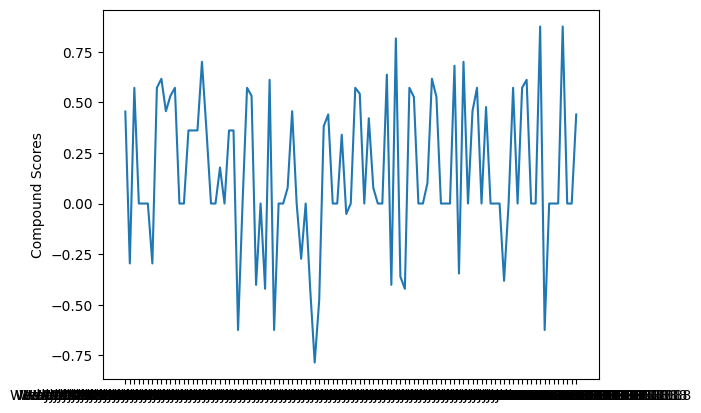

In [23]:
import matplotlib.pyplot as plt
plt.plot(nt_sorted['timestamp'],compound_scores)
plt.ylabel('Compound Scores')
plt.show()

In [24]:
negatives=nt_sorted[nt_sorted['sentiment_score']<0.0]
negatives

,id,text,timestamp,source,symbols,company_names,url,verified,sentiment_score
26223,1019690300187533300,RT @blackbullforex: Excluding FAANG Stocks The...,Wed Jul 18 21:08:07 +0000 2018,dexoidan,NFLX,Netflix,NaN,False,-0.2960
26278,1019691305767702500,RT @WaterMartyr: Buyer of $CL_F here. #Oil #fu...,Wed Jul 18 21:12:06 +0000 2018,Jabato111111,NFLX,Netflix,NaN,False,-0.2960
26582,1019696563977904100,Distorted US yield curve still a warning sign ...,Wed Jul 18 21:33:00 +0000 2018,StockBoardAsset,NFLX,Netflix,NaN,False,-0.6249
26652,1019697875973038100,$NFLX subscriber numbers disappoint @YahooFina...,Wed Jul 18 21:38:13 +0000 2018,Boutonski_Films,NFLX,Netflix,http://dld.bz/gUv4d,False,-0.4019
26718,1019699441341796400,RT @ali: Is Wall Street going to trigger a mid...,Wed Jul 18 21:44:26 +0000 2018,ali,NFLX,Netflix,https://youtu.be/OV0ccoClPyQ,False,-0.4215
26792,1019700893204168700,"RT @StockBoardAsset: ""Distorted US yield curve...",Wed Jul 18 21:50:12 +0000 2018,Black_Swan5555,NFLX,Netflix,NaN,False,-0.6249
26874,1019702992348504000,My gut sneaky suspecion: $SPX rug pull time. G...,Wed Jul 18 21:58:33 +0000 2018,LottoCalls,NFLX,Netflix,https://twitter.com/i/web/status/1019702992348...,False,-0.2732
26938,1019704214551957500,RT @ali: Is Wall Street going to trigger a mid...,Wed Jul 18 22:03:24 +0000 2018,mikeythom1977,NFLX,Netflix,https://youtu.be/OV0ccoClPyQ,False,-0.4215
26969,1019704996793905200,WTF $NFLX is not back to 423.21 yet? But $MS s...,Wed Jul 18 22:06:31 +0000 2018,SmartTraderTips,NFLX,Netflix,https://twitter.com/i/web/status/1019704996793...,False,-0.7855
27041,1019706252979527700,Had $BABA 197.5 calls @ .50 but it was not goo...,Wed Jul 18 22:11:30 +0000 2018,OptionsSTrader1,NFLX,Netflix,NaN,False,-0.4782


In [25]:
positives=nt_sorted[nt_sorted['sentiment_score']>0.0]
positives

,id,text,timestamp,source,symbols,company_names,url,verified,sentiment_score
26216,1019690098236055600,Netflix $NFLX just released quarterly 10-Q. Q...,Wed Jul 18 21:07:19 +0000 2018,Feedmeistercom,NFLX,Netflix,NaN,False,0.4545
26236,1019690538398707700,RT @RampCapitalLLC: Here is where $FANG was tr...,Wed Jul 18 21:09:03 +0000 2018,hs_traders,NFLX,Netflix,NaN,False,0.5719
26330,1019692044682498000,RT @RampCapitalLLC: Here is where $FANG was tr...,Wed Jul 18 21:15:03 +0000 2018,c_townsend2,NFLX,Netflix,NaN,False,0.5719
26332,1019692061682012200,NOW OFFERING 7 Day FREE Trial to options day ...,Wed Jul 18 21:15:07 +0000 2018,optionalarmchat,NFLX,Netflix,http://ow.ly/bbVr30kY55t,False,0.6166
26356,1019692591678279700,RT @GS_CapSF: How much you’re speculating depe...,Wed Jul 18 21:17:13 +0000 2018,MT__Bigsky,NFLX,Netflix,NaN,False,0.4563
26359,1019692619419578400,RT @WallStJesus: 🔥TODAY'S ACTIVE FLOW: $NFLX $...,Wed Jul 18 21:17:20 +0000 2018,FeldbergMt,NFLX,Netflix,NaN,False,0.5319
26379,1019693071456403500,RT @RampCapitalLLC: Here is where $FANG was tr...,Wed Jul 18 21:19:07 +0000 2018,RealBryanWatson,NFLX,Netflix,NaN,False,0.5719
26458,1019694489990905900,$MS expecting a $BAC like move when it reporte...,Wed Jul 18 21:24:46 +0000 2018,_Louie__,NFLX,Netflix,https://twitter.com/i/web/status/1019694489990...,False,0.3612
26461,1019694549738770400,Netflix To Bring Comedy To New Sirius XM Chann...,Wed Jul 18 21:25:00 +0000 2018,Benzinga,NFLX,Netflix,https://benzinga.com/z/12038245,True,0.3612
26462,1019694552872087600,RT @Benzinga: Netflix To Bring Comedy To New S...,Wed Jul 18 21:25:01 +0000 2018,tradnews_,NFLX,Netflix,https://benzinga.com/z/12038245,False,0.3612


In [32]:
neutral=nt_sorted[nt_sorted['sentiment_score']==0.0]
neutral

,id,text,timestamp,source,symbols,company_names,url,verified,sentiment_score
26239,1019690604559851500,RT @SevenPointsCap: Trader Takeaways 7.18.18 b...,Wed Jul 18 21:09:19 +0000 2018,clovisskyline,NFLX,Netflix,http://youtu.be/MLmX7WMEBVM?a,False,0.0
26241,1019690654383759400,#NASDAQ MOST VOLUME $HMNY -9.09% [Volume: +82...,Wed Jul 18 21:09:31 +0000 2018,Market_Scanner,NFLX,Netflix,https://twitter.com/i/web/status/1019690654383...,False,0.0
26245,1019690745727475700,New article on $NFLX at https://t.co/WpN8WdlXy...,Wed Jul 18 21:09:53 +0000 2018,10minutetrading,NFLX,Netflix,https://ift.tt/2zXyoGS,False,0.0
26410,1019693633556140000,RT @pharris667: IBD Big Cap 20 w/Rank July 17 ...,Wed Jul 18 21:21:21 +0000 2018,hwy183,NFLX,Netflix,NaN,False,0.0
26437,1019694105834803200,When I try to get in on some hot $NFLX calls h...,Wed Jul 18 21:23:14 +0000 2018,ttttt0mmmmm,NFLX,Netflix,NaN,False,0.0
26499,1019695140426932200,{VIDEO} Stock Analysis + Trade Ideas: $TSLA $N...,Wed Jul 18 21:27:21 +0000 2018,Trading_Analyst,NFLX,Netflix,https://twitter.com/i/web/status/1019695140426...,False,0.0
26548,1019696172955512800,RT @SevenPointsCap: Trader Takeaways 7.18.18 b...,Wed Jul 18 21:31:27 +0000 2018,Michael_Katz11,NFLX,Netflix,http://youtu.be/MLmX7WMEBVM?a,False,0.0
26557,1019696314756550700,RT @Sandro_power: Live Stream Tonight 9:30PM e...,Wed Jul 18 21:32:01 +0000 2018,CrispPowt,NFLX,Netflix,NaN,False,0.0
26597,1019696753661050900,July 18 Wednesday $NFLX closed $375.13 Bullis...,Wed Jul 18 21:33:45 +0000 2018,ericdavis221,NFLX,Netflix,NaN,False,0.0
26683,1019698586379063300,$NFLX get back on the train before it really t...,Wed Jul 18 21:41:02 +0000 2018,RTradesCapital,NFLX,Netflix,NaN,False,0.0
